# Zomato Restaurant Rating Predictor
### Data Preprocessing & Feature Engineering

This notebook covers the full preprocessing pipeline for the Zomato Bangalore dataset:
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering (binary encoding, target encoding)
- Saving cleaned data and artifacts for model training

## 1. Imports & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [12]:
from google.colab import files
uploaded = files.upload()

Saving Zomato.csv to Zomato (2).csv


In [13]:
df = pd.read_csv('Zomato.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7105, 12)


,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,Unnamed: 9,area,local address
0,0,#FeelTheROLL,Quick Bites,3.4,7,200,No,No,Fast Food,0,Bellandur,Bellandur
1,1,#L-81 Cafe,Quick Bites,3.9,48,400,Yes,No,"Fast Food, Beverages",1,"Byresandra,Tavarekere,Madiwala",HSR
2,2,#refuel,Cafe,3.7,37,400,Yes,No,"Cafe, Beverages",2,Bannerghatta Road,Bannerghatta Road
3,3,'@ Biryani Central,Casual Dining,2.7,135,550,Yes,No,"Biryani, Mughlai, Chinese",3,Marathahalli,Marathahalli
4,4,'@ The Bbq,Casual Dining,2.8,40,700,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",4,Bellandur,Bellandur


## 2. Exploratory Data Analysis (EDA)

In [14]:
df.describe()

,Unnamed: 0,rate (out of 5),num of ratings,avg cost (two people),Unnamed: 9
count,7105.000000,7105.000000,7105.000000,7105.000000,7105.000000
mean,3552.000000,3.480619,188.921042,535.952006,3552.000000
std,2051.181164,0.574133,592.171049,463.554352,2051.181164
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1776.000000,3.200000,16.000000,300.000000,1776.000000
50%,3552.000000,3.500000,40.000000,400.000000,3552.000000
75%,5328.000000,3.800000,128.000000,600.000000,5328.000000
max,7104.000000,4.900000,16345.000000,6000.000000,7104.000000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             7105 non-null   int64  
 1   restaurant name        7105 non-null   object 
 2   restaurant type        7105 non-null   object 
 3   rate (out of 5)        7105 non-null   float64
 4   num of ratings         7105 non-null   int64  
 5   avg cost (two people)  7105 non-null   int64  
 6   online_order           7105 non-null   object 
 7   table booking          7105 non-null   object 
 8   cuisines type          7105 non-null   object 
 9   Unnamed: 9             7105 non-null   int64  
 10  area                   7105 non-null   object 
 11  local address          7105 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 666.2+ KB


In [16]:
# Check for missing values
df.isnull().sum()

,0
Unnamed: 0,0
restaurant name,0
restaurant type,0
rate (out of 5),0
num of ratings,0
avg cost (two people),0
online_order,0
table booking,0
cuisines type,0
Unnamed: 9,0


In [17]:
# Target variable distribution
df['rate (out of 5)'].describe()

,rate (out of 5)
count,7105.000000
mean,3.480619
std,0.574133
min,0.000000
25%,3.200000
50%,3.500000
75%,3.800000
max,4.900000


In [18]:
# Restaurant type distribution
df['restaurant type'].value_counts()

,count
restaurant type,
Quick Bites,2840
Casual Dining,1634
Cafe,403
Delivery,358
"Takeaway, Delivery",289
...,...
"Food Court, Beverage Shop",1
"Quick Bites, Food Court",1
"Casual Dining, Sweet Shop",1


In [19]:
# Area distribution
df['area'].value_counts()

,count
area,
"Byresandra,Tavarekere,Madiwala",798
Bannerghatta Road,552
Brookefield,477
Brigade Road,464
Indiranagar,455
Electronic City,403
Malleshwaram,402
Kalyan Nagar,384
Bellandur,361


<Axes: xlabel='rate (out of 5)'>

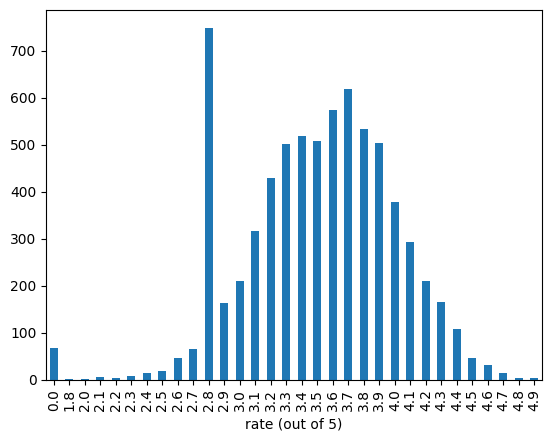

In [20]:
df['rate (out of 5)'].value_counts().sort_index().plot(kind='bar')

## 3. Data Cleaning

Key steps:
- Rename columns for consistency
- Drop irrelevant columns (`Unnamed: 0`, `Unnamed: 9`)
- Clean the `area` column — some rows had multi-part entries like `Byresandra,Tavarekere,Madiwala`. We extract the last part as the canonical area name.

In [ ]:
df = df.rename(columns={
    'restaurant name': 'name',
    'restaurant type': 'rest_type',
    'rate (out of 5)': 'rate',
    'num of ratings': 'num_ratings',
    'avg cost (two people)': 'avg_cost',
    'table booking': 'table_booking',
    'cuisines type': 'cuisines',
    'local address': 'local_address'
})
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 9'], errors='ignore')
print(df.columns.tolist())

['name', 'rest_type', 'rate', 'num_ratings', 'avg_cost', 'online_order', 'table_booking', 'cuisines', 'area', 'local_address']


In [ ]:
# Extract canonical area name from multi-part entries
df['area_clean'] = df['area'].str.split(',').str[-1].str.strip()

print(f'Unique areas reduced from {df["area"].nunique()} to {df["area_clean"].nunique()}')
print('\nExample fix:')
print(df[df['area'].str.contains('Byresandra')][['area', 'area_clean']].head(3))

Unique areas reduced from 30 to 30

Example fix:
                             area area_clean
1  Byresandra,Tavarekere,Madiwala   Madiwala
8  Byresandra,Tavarekere,Madiwala   Madiwala
9  Byresandra,Tavarekere,Madiwala   Madiwala


In [ ]:
# Encode online_order and table_booking as binary (Yes=1, No=0)
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['table_booking'] = df['table_booking'].map({'Yes': 1, 'No': 0})

## 4. Feature Engineering

### 4a. Restaurant Type — Binary Encoding
Each restaurant type becomes a binary column (`is_quick_bites`, `is_cafe`, etc.).
We use `str.contains()` because a restaurant can belong to multiple types.

### 4b. Cuisine — Binary Encoding
Same approach for cuisines. Each cuisine gets its own binary column.

### 4c. Area — Target Encoding
Instead of one-hot encoding area (which would create 50+ columns), we replace each area with the **mean rating of all restaurants in that area**. This captures the area's quality signal in a single numeric column (`encoded_area`).

### 4d. Additional Features
- `area_avg_cost` — average cost per area (captures price tier of the neighborhood)
- `competition_density` — number of same-type restaurants in the same area
- `price_position` — restaurant's cost relative to its area average (above/below average price)

In [ ]:
# Binary encoding for restaurant types
main_types = [
    'Quick Bites', 'Casual Dining', 'Cafe',
    'Delivery', 'Dessert Parlor', 'Bakery',
    'Beverage Shop', 'Bar', 'Food Court',
    'Fine Dining', 'Lounge', 'Sweet Shop', 'Pub'
]
for t in main_types:
    col_name = 'is_' + t.lower().replace(' ', '_')
    df[col_name] = df['rest_type'].str.contains(t).astype(int)

# Verify encoding
binary_cols = ['is_' + t.lower().replace(' ', '_') for t in main_types]
print(df[binary_cols].sum())

is_quick_bites       3000
is_casual_dining     1928
is_cafe               504
is_delivery           647
is_dessert_parlor     298
is_bakery             217
is_beverage_shop      175
is_bar                279
is_food_court          96
is_fine_dining         89
is_lounge              79
is_sweet_shop          91
is_pub                 88
dtype: int64


In [ ]:
# Binary encoding for cuisines
all_cuisine = df['cuisines'].str.split(',').explode().str.strip().unique()

for c in all_cuisine:
    col_name = 'is_' + c.lower().replace(' ', '_')
    df[col_name] = df['cuisines'].str.contains(c).astype(int)

/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_8269/2431730342.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df['cuisines'].str.contains(c).astype(int)
/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_8269/2431730342.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df['cuisines'].str.contains(c).astype(int)
/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_8269/2431730342.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [ ]:
# Area-level aggregate features
df['area_avg_rating'] = df.groupby('area_clean')['rate'].transform('mean')
df['area_avg_cost'] = df.groupby('area_clean')['avg_cost'].transform('mean')
df['competition_density'] = df.groupby(['area_clean', 'rest_type'])['name'].transform('count')
df['price_position'] = df['avg_cost'] / df['area_avg_cost']

/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_8269/2956956203.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['area_avg_rating'] = df.groupby('area_clean')['rate'].transform('mean')
/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_8269/2956956203.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['area_avg_cost'] = df.groupby('area_clean')['avg_cost'].transform('mean')
/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_8269/2956956203.py:4: PerformanceWarning: DataFrame is highly fragmen

In [ ]:
# Target encoding for area: replace area name with mean rating of that area
area_rating = df.groupby('area_clean')['rate'].mean()
df['encoded_area'] = df['area_clean'].map(dict(area_rating))

# Save area_rating mapping for use in Streamlit app
pickle.dump(area_rating, open('area_rating.pkl', 'wb'))
print('area_rating.pkl saved')

area_rating.pkl saved


/var/folders/zy/_h0gzvdj74nfr2n0x8db16dm0000gn/T/ipykernel_8269/1180288879.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['encoded_area'] = df['area_clean'].map(dict(area_rating))


## 5. Final Cleanup

- Drop non-numeric / text columns that have been encoded
- Drop low-frequency cuisine columns (< 50 occurrences) to reduce noise
- Save final feature set

In [ ]:
# Drop original text columns — all information is now encoded
df = df.drop(columns=['name', 'rest_type', 'cuisines', 'area', 'local_address', 'area_clean'], errors='ignore')
print(f'Shape after dropping text columns: {df.shape}')

Shape after dropping text columns: (7105, 127)


In [ ]:
# Drop low-frequency cuisine binary columns (< 50 restaurants)
# These add noise without enough signal for the model to learn from
is_cols = df.columns[df.columns.str.startswith('is_')]
is_sum = df[is_cols].sum()
low_freq = is_sum[is_sum < 50].index

print(f'Dropping {len(low_freq)} low-frequency columns: {list(low_freq)}')
df = df.drop(columns=low_freq, errors='ignore')
print(f'Final shape: {df.shape}')

Dropping 65 low-frequency columns: ['is_japanese', 'is_malaysian', 'is_vietnamese', 'is_korean', 'is_tibetan', 'is_nepalese', 'is_middle_eastern', 'is_bar_food', 'is_french', 'is_oriya', 'is_chettinad', 'is_lebanese', 'is_afghan', 'is_modern_indian', 'is_awadhi', 'is_sushi', 'is_burmese', 'is_indonesian', 'is_assamese', 'is_iranian', 'is_charcoal_chicken', 'is_kashmiri', 'is_singaporean', 'is_spanish', 'is_hot_dogs', 'is_tamil', 'is_coffee', 'is_tea', 'is_maharashtrian', 'is_north_eastern', 'is_bihari', 'is_rajasthani', 'is_lucknowi', 'is_gujarati', 'is_bubble_tea', 'is_bohri', 'is_turkish', 'is_tex-mex', 'is_wraps', 'is_german', 'is_drinks_only', 'is_konkan', 'is_goan', 'is_south_american', 'is_roast_chicken', 'is_naga', 'is_jewish', 'is_vegan', 'is_greek', 'is_african', 'is_grill', 'is_afghani', 'is_parsi', 'is_mongolian', 'is_portuguese', 'is_australian', 'is_paan', 'is_british', 'is_sindhi', 'is_sri_lankan', 'is_pan_asian', 'is_russian', 'is_raw_meats', 'is_belgian', 'is_cantonese'

In [ ]:
df.head()

,rate,num_ratings,avg_cost,online_order,table_booking,is_quick_bites,is_casual_dining,is_cafe,is_delivery,is_dessert_parlor,...,is_bengali,is_mangalorean,is_juices,is_mexican,is_indian,area_avg_rating,area_avg_cost,competition_density,price_position,encoded_area
0,3.4,7,200,0,0,1,0,0,0,0,...,0,0,0,0,0,3.475900,542.742382,118,0.368499,3.475900
1,3.9,48,400,1,0,1,0,0,0,0,...,0,0,0,0,0,3.583960,486.015038,316,0.823020,3.583960
2,3.7,37,400,1,0,0,0,1,0,0,...,0,0,0,0,0,3.430072,446.974638,33,0.894905,3.430072
3,2.7,135,550,1,0,0,1,0,0,0,...,0,0,0,0,0,3.407692,516.730769,61,1.064384,3.407692
4,2.8,40,700,1,0,0,1,0,0,0,...,0,0,0,0,1,3.475900,542.742382,101,1.289746,3.475900


## 6. Save Artifacts

In [ ]:
# Save cleaned dataset
df.to_csv('zomato_cleaned.csv', index=False)
print('zomato_cleaned.csv saved')

# Save feature column names (used by Streamlit app to build input DataFrame)
pickle.dump(df.drop(columns=['rate']).columns, open('feature_columns.pkl', 'wb'))
print('feature_columns.pkl saved')

# Verify
feature_columns = pickle.load(open('feature_columns.pkl', 'rb'))
print(f'Total features: {len(feature_columns)}')
print(f'Feature columns: {list(feature_columns)}')

zomato_cleaned.csv saved
feature_columns.pkl saved
Total features: 61
Feature columns: ['num_ratings', 'avg_cost', 'online_order', 'table_booking', 'is_quick_bites', 'is_casual_dining', 'is_cafe', 'is_delivery', 'is_dessert_parlor', 'is_bakery', 'is_beverage_shop', 'is_bar', 'is_food_court', 'is_fine_dining', 'is_lounge', 'is_sweet_shop', 'is_pub', 'is_fast_food', 'is_beverages', 'is_biryani', 'is_mughlai', 'is_chinese', 'is_bbq', 'is_continental', 'is_north_indian', 'is_italian', 'is_arabian', 'is_sandwich', 'is_rolls', 'is_burger', 'is_kebab', 'is_asian', 'is_european', 'is_pizza', 'is_salad', 'is_street_food', 'is_thai', 'is_south_indian', 'is_kerala', 'is_seafood', 'is_american', 'is_steak', 'is_momos', 'is_mediterranean', 'is_finger_food', 'is_ice_cream', 'is_mithai', 'is_andhra', 'is_desserts', 'is_healthy_food', 'is_hyderabadi', 'is_bengali', 'is_mangalorean', 'is_juices', 'is_mexican', 'is_indian', 'area_avg_rating', 'area_avg_cost', 'competition_density', 'price_position', 'en